<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>


<h1><font color="#113D68" size=5>Parte 4. Mejorar la Generalización en modelos</font></h1>

<h1><font color="#113D68" size=4>11. Entender el comportamiento del modelo visualizando métricas
</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Métricas en un bucle de entrenamiento](#section1)
* [2. Graficar el historial de Entrenamiento](#section2)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

Puedes aprender mucho sobre redes neuronales y modelos de aprendizaje profundo observando su rendimiento a lo largo del tiempo durante el entrenamiento. Por ejemplo, si ves que el accuracy del entrenamiento empeora con las épocas de entrenamiento, sabes que tienes un problema con la optimización. Probablemente, tu tasa de aprendizaje es demasiado rápida. En este capítulo, descubrirás cómo revisar y visualizar el rendimiento de los modelos de PyTorch a lo largo del tiempo durante el entrenamiento. Al completar esta clase, sabrás:

- Qué métricas recopilar durante el entrenamiento
- Cómo graficar las métricas en conjuntos de datos de entrenamiento y validación a partir del entrenamiento
- Cómo interpretar la gráfica para hablar sobre el modelo y el progreso del entrenamiento

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
[PyTorch tutorials.](https://pytorch.org/tutorials/)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Métricas en un bucle de entrenamiento</font>

Este ejemplo demuestra cómo implementar un bucle de entrenamiento básico para un problema de regresión, incluyendo la recopilación y visualización de métricas de pérdida tanto para el conjunto de entrenamiento como para el de prueba.

- Proceso de entrenamiento en aprendizaje profundo:

  1. Pase hacia adelante: Inferir métrica de pérdida

  2. Pase hacia atrás: Calcular gradiente de la pérdida
  
  3. Actualización: Aplicar gradiente a parámetros del modelo

- Expectativa en entrenamiento correcto:
  - Disminución de la métrica de pérdida

- Elección de métrica de pérdida:
  - Depende del tipo de problema

- Métricas para problemas de regresión:

  - MSE (Error Cuadrático Medio)

  - RMSE (Error Cuadrático Medio de Raíz)

  - MAE (Error Absoluto Medio)

  - MAPE (Error Absoluto Porcentual Medio)

  - Error máximo (no usado como métrica de pérdida)

- Métricas para problemas de clasificación:
  - Entropía cruzada (métrica de pérdida principal)

  - Accuracy

  - Tasa de verdaderos positivos

  - Precisión

  - Recall

  - Puntuaciones F1

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`L1Loss`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X, y = data.data, data.target

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

loss_fn = nn.MSELoss()
mae_fn = nn.L1Loss()  # MAE como métrica adicional
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 100  
batch_size = 32  
batch_start = torch.arange(0, len(X_train), batch_size)

- Seguimiento del progreso:
  - Opción de imprimir la métrica de pérdida en cada paso

  - Guardar valores para visualización posterior

- Consideración importante:
  - Guardar el valor del tensor, no el tensor completo

  - Evita almacenar datos adicionales para diferenciación automática

- Evaluación con conjunto de test:
  - Realizada generalmente una vez por época

  - Resultados guardados para visualización posterior

  - Posibilidad de obtener múltiples métricas

- Buenas prácticas en evaluación:
  - Cambiar el modelo a modo de evaluación

  - Usar contexto `no_grad()` para evitar diferenciación automática

- Comparación de métricas:
  - MSE de entrenamiento: calculado por lote, más frecuente

  - Métricas de test: calculadas por época, basadas en conjunto completo

  - No son directamente comparables

- Manejo del ruido en MSE de entrenamiento:
  - Resumir MSE de un período a un solo número (ej. media)

  - Facilita comparación con datos del conjunto de test

Esta implementación proporciona una base para el seguimiento y evaluación del progreso del entrenamiento, aunque se pueden aplicar mejoras para una comparación más precisa entre métricas de entrenamiento y prueba.

In [2]:
train_mse_history = []
test_mse_history = []
test_mae_history = []

for epoch in range(n_epochs):
    model.train()
    epoch_mse = []
    for start in batch_start:
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        epoch_mse.append(float(loss))  # float(): guarda el valor, no el tensor con su grafo
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    mean_mse = sum(epoch_mse) / len(epoch_mse)
    train_mse_history.append(mean_mse)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
        mse = loss_fn(y_pred, y_test)
        mae = mae_fn(y_pred, y_test)
        test_mse_history.append(float(mse))
        test_mae_history.append(float(mae))

/tmp/ipykernel_476573/3756211515.py:13: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  epoch_mse.append(float(loss))  # float(): guarda el valor, no el tensor con su grafo


---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Graficar el historial de Entrenamiento</font>

Los gráficos como este pueden proporcionar indicios útiles sobre el entrenamiento del modelo, tales como:
- Su velocidad de convergencia a lo largo de las épocas (pendiente)

- Si el modelo puede haber convergido ya (plateau de la línea)

- Si el modelo puede estar sobreajustándose a los datos de entrenamiento (inflexión en la línea de validación)

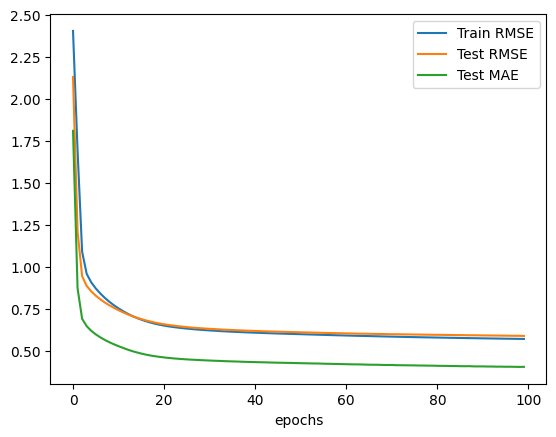

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.sqrt(train_mse_history), label="Train RMSE")
plt.plot(np.sqrt(test_mse_history), label="Test RMSE")
plt.plot(test_mae_history, label="Test MAE")
plt.xlabel("epochs")
plt.legend()
plt.show()

**Notas importantes:**
- En un ejemplo de regresión como el anterior, las métricas MAE y MSE deberían disminuir si el modelo mejora. 

    - Sin embargo, en un ejemplo de clasificación, la métrica accuracy debería aumentar mientras que la pérdida de entropía cruzada debería disminuir a medida que se realice más entrenamiento. 

- Estas curvas deberían eventualmente aplanarse, lo que significa que no puedes mejorar el modelo más allá de lo que permite el conjunto de datos actual, el diseño del modelo y los algoritmos. 
    - Quieres que esto suceda lo antes posible, para que tu modelo converja más rápido y tu entrenamiento sea eficiente. 
    
    - También deseas que la métrica se aplana en una región de alta precisión o baja pérdida, de modo que tu modelo sea efectivo en la predicción.

- Otra propiedad a observar en los gráficos es cuán diferentes son las métricas de entrenamiento y validación. 
    
    - En el caso anterior, puedes ver que el RMSE del conjunto de entrenamiento es más alto que el RMSE del conjunto de prueba al principio, pero muy pronto, las curvas se cruzan y el RMSE del conjunto de prueba es más alto al final. 
    
    - Esto es esperado, ya que eventualmente el modelo se ajustará mejor al conjunto de entrenamiento, pero es el conjunto de prueba el que puede predecir cómo se desempeñará el modelo en datos no vistos.

- Debes tener cuidado al interpretar las curvas o métricas en una escala microscópica. 

    - En el gráfico anterior, puedes ver que el RMSE del conjunto de entrenamiento es extremadamente alto en comparación con el del conjunto de prueba en la época 0. 
    
    - Su diferencia puede no ser tan drástica, pero dado que recopilaste el RMSE del conjunto de entrenamiento tomando el MSE de cada paso durante la primera época, probablemente tu modelo no estaba funcionando bien en los primeros pasos, pero mucho mejor en los últimos pasos de la época. 
    
    - Tomar un promedio a través de todos los pasos puede no ser una comparación justa, ya que el MSE del conjunto de prueba se basa en el modelo después del último paso.

- Tu modelo está sobreajustado si ves que la métrica del conjunto de entrenamiento es mucho mejor que la del conjunto de test. 

    - Esto puede indicar que deberías detener tu entrenamiento en una época anterior o que el diseño de tu modelo necesita alguna regularización, como una capa de dropout.

- En el gráfico anterior, aunque recopilaste el error cuadrático medio (MSE) para el problema de regresión, en realidad graficaste el error cuadrático medio de raíz (RMSE) en su lugar, para poder compararlo con el error absoluto medio (MAE) en la misma escala. 

    - Probablemente también deberías recopilar el MAE del conjunto de entrenamiento. 
    
    - Las dos curvas de MAE deberían comportarse de manera similar a las de las curvas de RMSE.

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>